<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
!pip install -q gdown sentence-transformers huggingface_hub transformers peft langchain-community langchain-text-splitters langchain langchain-classic langchain-core langchain-chroma langchain-openai datasets ragatouille umap-learn

In [ ]:
!pip show langchain-classic

Name: langchain-classic
Version: 1.0.4
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langchain-text-splitters, langsmith, pydantic, pyyaml, requests, sqlalchemy
Required-by: langchain-community


In [ ]:
import langchain_classic
print(langchain_classic.__version__)

1.0.4


**ВАЖНО!** Сначала выполнить ячейку импортов следующую за следующей. Получить ошибку, и затем выполнить следующую ячейку. Потратил кучу времени на эксперименты

In [ ]:
import sys
sys.modules['langchain.retrievers'] = langchain_classic.retrievers

In [ ]:
import gdown
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from typing import Optional, List, Tuple
from langchain_core.documents import Document
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker

from ragatouille import RAGPretrainedModel

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки
from langchain_text_splitters  import CharacterTextSplitter

# pd.set_option("display.max_colwidth", None)

/tmp/ipykernel_120884/2700421148.py:21: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


## Загрузка данных (4 балла)

In [ ]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=967edf03-b8ac-4ac6-9f8b-b3f6747b9584
To: /content/file.csv
100%|██████████| 672M/672M [00:10<00:00, 63.7MB/s]


In [ ]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [ ]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [ ]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

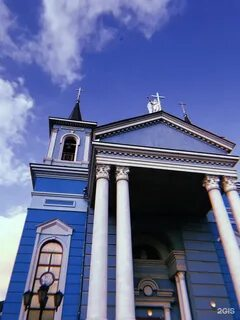

In [ ]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   14634 non-null  int64  
 1   Name         14634 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         14634 non-null  object 
 4   Lon          14634 non-null  float64
 5   Lat          14634 non-null  float64
 6   description  12078 non-null  object 
 7   image        14634 non-null  object 
 8   en_txt       14634 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ MB


In [ ]:
data.describe()

,Unnamed: 0,Lon,Lat
count,14634.000000,14634.000000,14634.000000
mean,1914.347205,45.625959,56.781887
std,1141.773608,8.210037,0.605826
min,0.000000,39.741951,56.103119
25%,928.000000,39.898258,56.307186
50%,1856.000000,40.413074,56.826569
75%,2897.750000,44.019402,57.613121
max,4371.000000,60.678642,57.765659


In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
Name,0
WikiData,2556
City,0
Lon,0
Lat,0
description,2556
image,0
en_txt,0


Для обработки в дальнейшем буду использовать поле **en_txt**, поскольку оно не содержит пустых данных

In [ ]:
data.isna().sum().sum()

np.int64(5112)

Считаю, что строки с незаполненным полем **WikiData** - **шум**

In [ ]:
data.dropna(subset=['WikiData'], inplace=True)

In [ ]:
data = data[data['en_txt'].str.strip() != '']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12078 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   12078 non-null  int64  
 1   Name         12078 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         12078 non-null  object 
 4   Lon          12078 non-null  float64
 5   Lat          12078 non-null  float64
 6   description  12078 non-null  object 
 7   image        12078 non-null  object 
 8   en_txt       12078 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 943.6+ KB


Интересно получилось: строки с незаполненным **WikiData** те же, что и с незаполненным **description**

In [ ]:
data.shape

(12078, 9)

In [ ]:
!pip install -q openai langchain-openai

In [ ]:
import openai
from langchain_openai import OpenAIEmbeddings
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [ ]:
# your code here - код ниже

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, min_df=2, max_df=0.8)
tfidf_matrix = vectorizer.fit_transform(data['en_txt'])

In [ ]:
# Для каждого документа вычисляется:
# - средний TF‑IDF (чем выше, тем больше редких слов)
# - долю уникальных слов (слова, которые встречаются только в этом документе)
feature_names = np.array(vectorizer.get_feature_names_out())
word_occ_doc_count = (tfidf_matrix > 0).sum(axis=0).A1  # сколько документов содержит каждое слово


In [ ]:
def compute_anomaly_scores(row_idx, tfidf_row):
    # tfidf_row – разреженный вектор для одного документа
    words_present = tfidf_row.indices
    if len(words_present) == 0:
        return 1.0, 0.0  # высокий score, чтобы отфильтровать
    # Доля уникальных слов (встречаются только в одном документе)
    unique_words = sum(1 for w in words_present if word_occ_doc_count[w] == 1)
    unique_ratio = unique_words / len(words_present)
    # Средний TF‑IDF
    mean_tfidf = tfidf_row.data.mean() if tfidf_row.data.size > 0 else 0
    return unique_ratio, mean_tfidf

In [ ]:
# Вычисление метрик для каждой записи датафрейма
scores = []
for idx in range(data.shape[0]):
    row = tfidf_matrix[idx]
    unique_ratio, mean_tfidf = compute_anomaly_scores(idx, row)
    scores.append((unique_ratio, mean_tfidf))

In [ ]:
# Заполнение метрик в датафрейме для каждой записи
data['unique_ratio'] = [s[0] for s in scores]
data['mean_tfidf'] = [s[1] for s in scores]

In [ ]:
# Признаки подозрительных записей:
# - высокая доля уникальных слов (>0.7) И/ИЛИ
# - очень низкий или очень высокий средний TF‑IDF (выход за 95-й перцентиль)
high_unique = data['unique_ratio'] > 0.7
low_tfidf = data['mean_tfidf'] < data['mean_tfidf'].quantile(0.05)
high_tfidf = data['mean_tfidf'] > data['mean_tfidf'].quantile(0.95)
suspicious = high_unique | low_tfidf | high_tfidf # индексы подозрительных записей

In [ ]:
# Очистка
data = data[~suspicious]

In [ ]:
data.shape

(10871, 11)

In [ ]:
# Группировка по (City, Name) – уникальное место
grouped = data.groupby(['City', 'Name'])

In [ ]:
grouped.ngroups

320

In [ ]:
grouped.size()

City       Name                                       
Владимир   église arménienne de Vladimir                  27
           Авиамеханический колледж                       29
           Белокаменные памятники Владимира и Суздаля     28
           Богородице-Рождественский мужской монастырь    27
           Бывшая водонапорная башня                      41
                                                          ..
Ярославль  церковь Иоанна Предтечи в Толчкове             55
           церковь Михаила Архангела                      38
           церковь Николая Чудотворца                     51
           церковь Николы Рублёного                       50
           часовня Казанской Богоматери                   35
Length: 320, dtype: int64

In [ ]:
# Первые 5 групп и их строки
for name, group in list(grouped)[:5]:
    print(f"Группа: {name}")
    print(f"Количество строк: {len(group)}")
    print(group[['Name', 'City']].head())
    print("=" * 25)

Группа: ('Владимир', 'église arménienne de Vladimir')
Количество строк: 27
                               Name      City
7732  église arménienne de Vladimir  Владимир
7733  église arménienne de Vladimir  Владимир
7734  église arménienne de Vladimir  Владимир
7735  église arménienne de Vladimir  Владимир
7736  église arménienne de Vladimir  Владимир
Группа: ('Владимир', 'Авиамеханический колледж')
Количество строк: 29
                          Name      City
6808  Авиамеханический колледж  Владимир
6809  Авиамеханический колледж  Владимир
6810  Авиамеханический колледж  Владимир
6811  Авиамеханический колледж  Владимир
6812  Авиамеханический колледж  Владимир
Группа: ('Владимир', 'Белокаменные памятники Владимира и Суздаля')
Количество строк: 28
                                            Name      City
7462  Белокаменные памятники Владимира и Суздаля  Владимир
7463  Белокаменные памятники Владимира и Суздаля  Владимир
7464  Белокаменные памятники Владимира и Суздаля  Владимир
7465  Бел

In [ ]:
# Для каждой группы нужно выбрать одно лучшее описание (самое длинное)
# В задании предлагется выбрать случайным образом - но мы палагаться на случай не будем
def select_best_description(group):
    """
    Если в группе несколько строк (разные описания одного места),
    выбираем самое длинное описание.
    """
    # Сортировка по длине 'full_text' (убывание)
    group_sorted = group.sort_values('en_txt', key=lambda x: x.str.len(), ascending=False)
    best_row = group_sorted.iloc[0].copy()

    # Запасной альтернативный вариант - вариант конкатенации (не более 2000 символов, чтобы не было слишком много)
    # texts = group['en_txt'].tolist()
    # concatenated = ' '.join(texts)
    # if len(concatenated) > 2000:
    #     concatenated = concatenated[:2000] + '...'
    # best_row['en_txt'] = concatenated
    # best_row['description'] = concatenated

    return best_row

# Применяем к каждой группе
selected_rows = []
for (city, name), group in grouped:
    if len(group) > 0:
        selected_rows.append(select_best_description(group))

df_selected = pd.DataFrame(selected_rows)

In [ ]:
df_selected.shape

(320, 11)

In [ ]:
df_selected.describe()

,Unnamed: 0,Lon,Lat,unique_ratio,mean_tfidf
count,320.000000,320.000000,320.000000,320.0,320.000000
mean,1790.225000,47.468782,56.852989,0.0,0.394244
std,1164.773047,8.836255,0.561347,0.0,0.039568
min,0.000000,39.741951,56.103119,0.0,0.345042
25%,758.500000,39.897792,56.326539,0.0,0.362668
50%,1685.500000,43.995440,56.835158,0.0,0.386283
75%,2814.500000,60.596297,57.614061,0.0,0.415400
max,4357.000000,60.678642,57.765659,0.0,0.535209


In [ ]:
df_selected.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt,unique_ratio,mean_tfidf
7742,991,église arménienne de Vladimir,Q18331756,Владимир,40.456497,56.154667,Армянская церковь в г. Владимир России,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a computer generated image of a rocky landscap...,0.0,0.401414
6822,71,Авиамеханический колледж,Q18786015,Владимир,40.387318,56.126278,Владимирский авиамеханический колледж,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are many people sitting in a classroom w...,0.0,0.386477
7487,736,Белокаменные памятники Владимира и Суздаля,Q838264,Владимир,40.416698,56.150002,Белокаменные памятники Владимира и Суздаля,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a bunch of pictures of different buildings and...,0.0,0.463537
7284,533,Богородице-Рождественский мужской монастырь,Q4089667,Владимир,40.414005,56.131298,Богородице-Рождественский монастырь (Владимир),/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed image of a church with a cross and a ch...,0.0,0.422079
7129,378,Бывшая водонапорная башня,Q4114100,Владимир,40.398781,56.125111,достопримечательность во Владимире,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,people standing in front of a tall brick build...,0.0,0.391559


In [ ]:
group_indices = grouped.groups
for i, (key, value) in enumerate(group_indices.items()):
    if i >= 10:
        break
    print(f"Group key: {key}, Indices (first 5): {list(value)[:5]}...")

Group key: ('Владимир', 'église arménienne de Vladimir'), Indices (first 5): [7732, 7733, 7734, 7735, 7736]...
Group key: ('Владимир', 'Авиамеханический колледж'), Indices (first 5): [6808, 6809, 6810, 6811, 6812]...
Group key: ('Владимир', 'Белокаменные памятники Владимира и Суздаля'), Indices (first 5): [7462, 7463, 7464, 7465, 7466]...
Group key: ('Владимир', 'Богородице-Рождественский мужской монастырь'), Indices (first 5): [7263, 7264, 7265, 7266, 7267]...
Group key: ('Владимир', 'Бывшая водонапорная башня'), Indices (first 5): [7119, 7120, 7121, 7122, 7123]...
Group key: ('Владимир', 'Владимиро-Суздальский музей-заповедник (центральный офис)'), Indices (first 5): [7675, 7676, 7677, 7678, 7679]...
Group key: ('Владимир', 'Владимирская духовная семинария'), Indices (first 5): [7702, 7703, 7704, 7705, 7706]...
Group key: ('Владимир', 'Владимирская митрополия'), Indices (first 5): [7646, 7647, 7648, 7649, 7653]...
Group key: ('Владимир', 'Владимирский академический областной драматич

In [ ]:
top_groups = grouped.size().nlargest(10)
top_groups

City             Name                                                 
Екатеринбург     улица Добролюбова                                        84
Нижний Новгород  Чкаловская лестница                                      64
Екатеринбург     Добровольцам-танкистам                                   60
Ярославль        Знаменская церковь                                       60
                 Н.А. Некрасову                                           59
                 Ф. Г. Волкову                                            59
Нижний Новгород  Ивановская башня                                         58
                 Церковь Знамения Божией Матери и святых Жен-Мироносиц    58
Ярославль        Фёдор Иванович Толбухин                                  58
                 Церковь Николая Надеина                                  58
dtype: int64

In [ ]:
df_selected.shape

(320, 11)

In [ ]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 7742 to 14215
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    320 non-null    int64  
 1   Name          320 non-null    object 
 2   WikiData      320 non-null    object 
 3   City          320 non-null    object 
 4   Lon           320 non-null    float64
 5   Lat           320 non-null    float64
 6   description   320 non-null    object 
 7   image         320 non-null    object 
 8   en_txt        320 non-null    object 
 9   unique_ratio  320 non-null    float64
 10  mean_tfidf    320 non-null    float64
dtypes: float64(4), int64(1), object(6)
memory usage: 30.0+ KB


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

**Указанная ссылка битая**

In [ ]:
# your code here - код ниже

In [ ]:
documents = []
for idx, row in df_selected.iterrows():
    content = row.get('description', '')

    metadata = {
        "name": row.get('Name', ''),
        "city": row.get('City', ''),
        "wiki_id": row.get('WikiData', ''),
        "image": row.get('image', '')
    }
    documents.append(Document(page_content=content, metadata=metadata))


embedding= OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding,
    persist_directory="./chroma_poi_db"  # папка для сохранения базы
)

In [ ]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

In [ ]:
# Сначала я пытался использовать RAGPretrainedModel для создания rerankera:
#
# from ragatouille import RAGPretrainedModel
# base_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
# reranker = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")
# compressor = reranker.as_langchain_compressor(k=5)
# compression_retriever = ContextualCompressionRetriever(
#    base_compressor=compressor, base_retriever=base_retriever
#)
#
# При этом возникает ошибка времени выполнения (полный trace не привожу - очень длинный):
#
# AttributeError: 'HF_ColBERT' object has no attribute 'all_tied_weights_keys'
#
# Чтобы я не делал - ошибку исправить не удалось. Как я понял, основная причина - несовместимость пакетов: transformers colbert-ai ragatouille
#
# Я решил использовать CrossEncoderReranker из LangChain. Уверяют, что качество сопоставимое с RAGatouille
#

In [ ]:
base_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
model = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")
compressor = CrossEncoderReranker(model=model, top_n=5)
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=base_retriever
)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [ ]:
import base64
from IPython.display import display, Image

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)

def format_docs(docs):
    return "\n\n---\n\n".join([doc.page_content for doc in docs])

def answer_question(question: str) -> str:
    # Поиск релевантных документов
    retrieved_docs = compression_retriever.invoke(question)

    for i, doc in enumerate(retrieved_docs):
        print(f"Документ {i+1}:")
        print(f"  Содержание: {doc.page_content[:100]}...")
        print(f"  Метаданные: {doc.metadata}")
        print(f"    - Название: {doc.metadata.get('name')}")
        print(f"    - Город: {doc.metadata.get('city')}")
        print(f"    - WikiData ID: {doc.metadata.get('wiki_id')}")

        img_data = base64.b64decode(doc.metadata['image'])
        display(Image(data=img_data))

        print("=" * 25)

    context = format_docs(retrieved_docs)
    prompt = f"""Ты — эксперт по туристическим достопримечательностям.
Используй только следующий контекст для ответа на вопрос.
Если ответа в контексте нет, честно скажи об этом. Ничего не придумывай от себя.

КОНТЕКСТ:
{context}

ВОПРОС: {question}

ОТВЕТ:"""

    response = llm.invoke(prompt)
    return response.content

Документ 1:
  Содержание: православный кладбищенский храм во Владимире...
  Метаданные: {'city': 'Владимир', 'name': 'Князь-Владимирская церковь', 'wiki_id': 'Q65062793', 'image': '...'}
    - Название: Князь-Владимирская церковь
    - Город: Владимир
    - WikiData ID: Q65062793


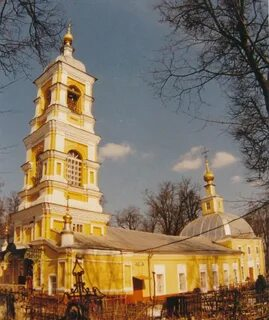

Документ 2:
  Содержание: Белокаменные памятники Владимира и Суздаля...
  Метаданные: {'image': '...', 'wiki_id': 'Q838264', 'city': 'Владимир', 'name': 'Белокаменные памятники Владимира и Суздаля'}
    - Название: Белокаменные памятники Владимира и Суздаля
    - Город: Владимир
    - WikiData ID: Q838264


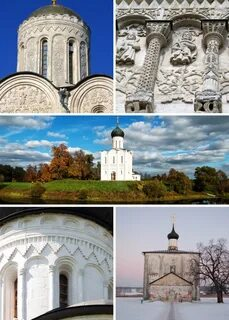

Документ 3:
  Содержание: католический храм в городе Владимир...
  Метаданные: {'city': 'Владимир', 'name': 'Костел Святого Розария Пресвятой Девы Марии Римско-Католической Церкви', 'wiki_id': 'Q3580427', 'image': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAFAAXADASIAAhEBAxEB/8QAHAAAAgIDAQEAAAAAAAAAAAAAAgMBBAAFBgcI/8QAQxAAAQMCBQIDBgMFBwIGAwAAAQACAwQRBRIhMUEGURMiYQcUMnGBkSOhwRVCUrHwFiQzYnKS0TTxJUSCk9LhU1SD/8QAGQEAAwEBAQAAAAAAAAAAAAAAAAECAwQF/8QAKhEAAgMAAgICAgMAAQUBAAAAAAECAxESIQQxE0EiUQUUMmEjUoGhsdH/2gAMAwEAAhEDEQA/APk94iku9l/KBcW1VchOI/C+SXay5TofZFkzM59tToEsI2GxPySBBBvlJcFjQWtNx8lgzOFiUbSCNfkkUiW6hTm1IsRpZSBYIH+blIY2P4Qsc/8AhNiOULDlZ34WEXjceyPQeywypyRtaODqtnFMJW3b9Vo4PN5XE+llZimMFQA03YR5j2K0jN7hLRuLowlMcHNu3UJl1sQ0MHKNvKW3lSOUg9jEQ3QohumMY3YohyhbsUQ5SANuya3lKbsmt3KYg7I7KA3RHZAmDZRl9UyyyyASF5fVZl9UyyyyA9CiEJCYQhISE

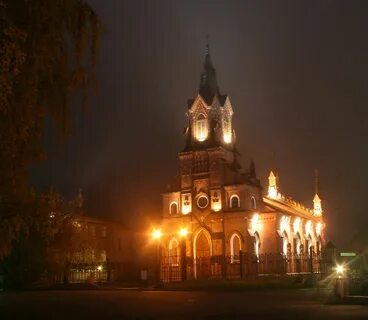

Документ 4:
  Содержание: памятник XII века во Владимире...
  Метаданные: {'wiki_id': 'Q775020', 'city': 'Владимир', 'name': 'Золотые ворота', 'image': '...'}
    - Название: Золотые ворота
    - Город: Владимир
    - WikiData ID: Q775020


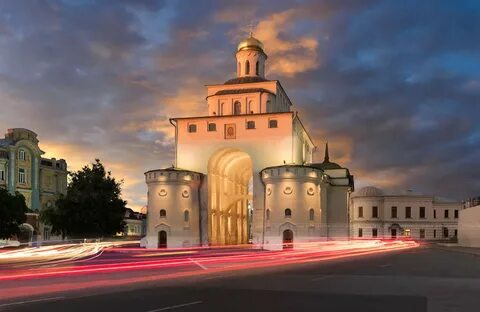

Документ 5:
  Содержание: достопримечательность во Владимире...
  Метаданные: {'name': 'Бывшая водонапорная башня', 'image': '...', 'city': 'Владимир', 'wiki_id': 'Q4114100'}
    - Название: Бывшая водонапорная башня
    - Город: Владимир
    - WikiData ID: Q4114100


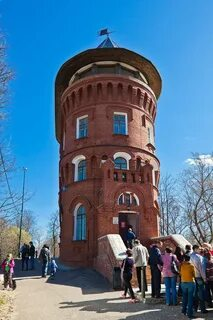

Во Владимире можно посетить православный кладбищенский храм, белокаменные памятники, католический храм и памятник XII века.


In [ ]:
question = "Какие интересные места можно посетить во Владимире?"
answer = answer_question(question)
print(answer)

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [ ]:
# your code here - код ниже

In [ ]:
texts = []
for _, row in df_selected.iterrows():
    text = f"Name: {row['Name']}\nCity: {row['City']}\nDescription: {row['en_txt']}"
    texts.append(text)
text_embeddings = embedding.embed_documents(texts)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
X = np.array(text_embeddings)  # форма (320, 1536)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Доля объяснённой дисперсии: {pca.explained_variance_ratio_}")

Доля объяснённой дисперсии: [0.08545816 0.06452947]


In [ ]:
!pip install -q umap-learn

In [ ]:
import umap

In [ ]:
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_reducer.fit_transform(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


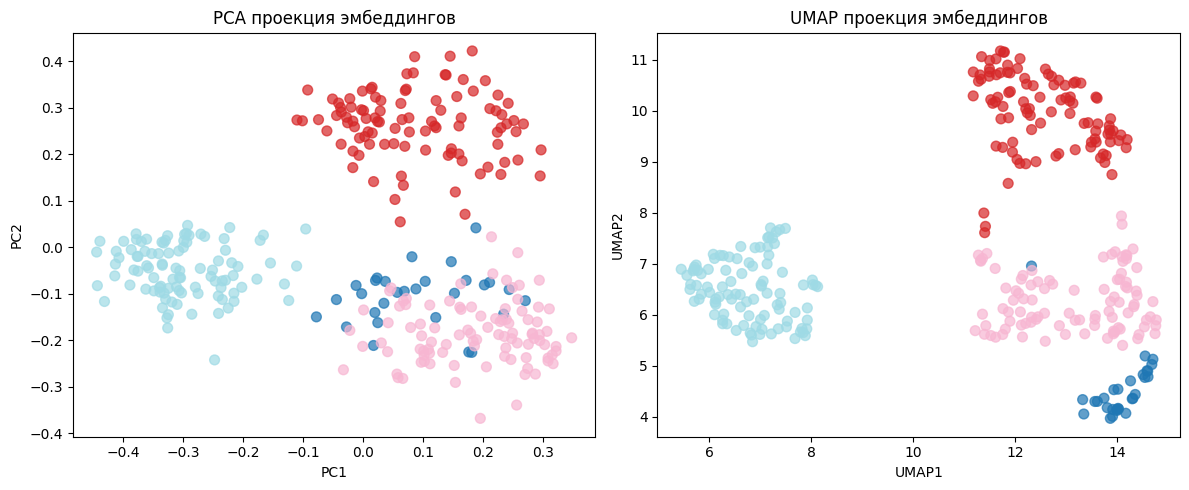

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cities = df_selected['City'].values
names = df_selected['Name'].values

unique_cities = list(set(cities))
city_to_color = {city: idx for idx, city in enumerate(unique_cities)}
colors = [city_to_color[city] for city in cities]

# PCA
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap='tab20', alpha=0.7, s=50)
plt.title('PCA проекция эмбеддингов')
plt.xlabel('PC1')
plt.ylabel('PC2')

# UMAP
plt.subplot(1, 2, 2)
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, cmap='tab20', alpha=0.7, s=50)
plt.title('UMAP проекция эмбеддингов')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
plt.show()

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

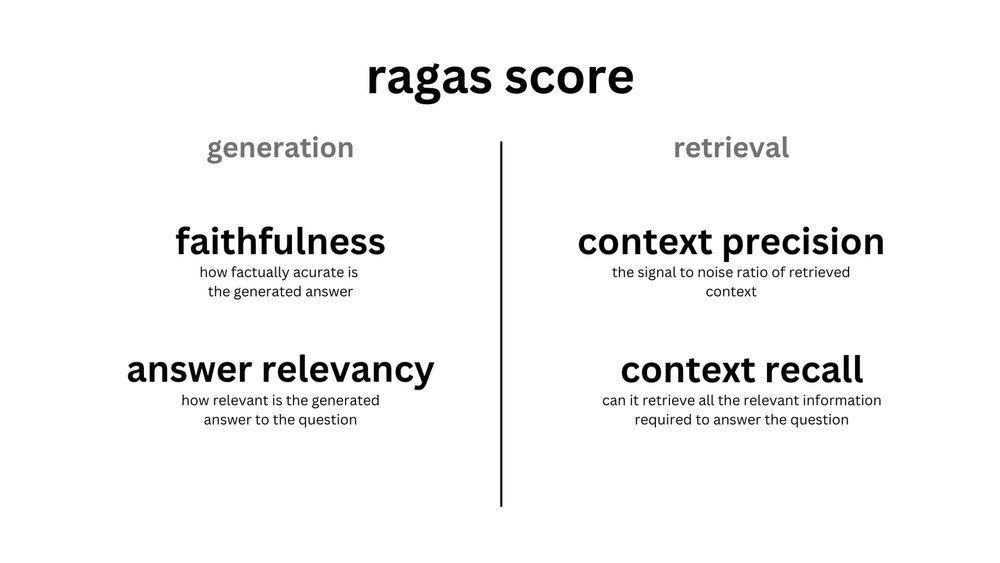

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
!pip install -q tqdm

In [ ]:
from openai import OpenAI

In [ ]:
def generate_question_from_description(description: str) -> str:
    """Генерирует один релевантный вопрос, ответ на который содержится в описании."""
    prompt = f"""На основе приведённого ниже описания достопримечательности придумай один вопрос,
на который можно ответить, используя только эту информацию. Вопрос должен быть содержательным,
не слишком узким и не слишком общим. Не добавляй ничего, кроме вопроса.

ОПИСАНИЕ:
{description}

ВОПРОС:"""
    client = OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.5
    )
    question = response.choices[0].message.content.strip()
    return question

In [ ]:
def get_rag_response(question: str): # Модификация answer_question
    """
    Возвращает:
        answer (str): сгенерированный ответ
        contexts (list[str]): список текстов релевантных документов (page_content)
    """
    retrieved_docs = compression_retriever.invoke(question)
    if not retrieved_docs:
        return "Не найдено релевантных документов.", []

    contexts = [doc.page_content for doc in retrieved_docs]
    context_text = "\n\n---\n\n".join(contexts)

    prompt = f"""Ты — эксперт по туристическим достопримечательностям.
Используй только следующий контекст для ответа на вопрос.
Если ответа в контексте нет, честно скажи об этом. Ничего не придумывай от себя.

КОНТЕКСТ:
{context_text}

ВОПРОС: {question}

ОТВЕТ:"""

    response = llm.invoke(prompt)
    return response.content, contexts

In [ ]:
def data_preprocess():
    # your code here

    # Создаём новые колонки с пустыми значениями (или списками)
    df_selected["question"] = ""
    df_selected["ground_truths"] = None   # будет list
    df_selected["answer"] = ""
    df_selected["contexts"] = None        # будет list

    for idx, row in tqdm(df_selected.iterrows(), total=len(df_selected), desc="Генерация данных"):

        desc_text = row.get("en_txt", "")

        try:
            question = generate_question_from_description(desc_text)
            answer, contexts = get_rag_response(question)

            df_selected.at[idx, "question"] = question
            df_selected.at[idx, "ground_truths"] = [desc_text]   # эталон – само описание
            df_selected.at[idx, "answer"] = answer
            df_selected.at[idx, "contexts"] = contexts
        except Exception as e:
            print(f"Ошибка на строке {idx} ({row.get('Name', '')}): {e}")
            continue

    print("Готово. Исходный датафрейм дополнен колонками: question, ground_truths, answer, contexts")
    df_selected.to_csv("df_selected_with_qa.csv", index=False)

    return None

In [ ]:
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
def get_embedding(text: str) -> np.ndarray:
    """Получает эмбеддинг текста через OpenAI."""
    client = OpenAI()
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )
    return np.array(response.data[0].embedding).reshape(1, -1) # .reshape(1, -1) для cosine_similarity: она ожидает двумерные массивы (матрицы), где каждая строка — отдельный вектор

def answer_relevancy(question: str, answer: str, n: int = 3):
    # your code here

    client = OpenAI()
    prompt = f"""Ты — ИИ-помощник. Получив ответ, сгенерируй ровно {n} различных вопросов, на которые этот ответ может быть правильным и релевантным..
Answer: {answer}

Формат ответа: один вопрос на строку, пронумерованный или с тире. Ничего лишнего не включать.
"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.5,
    )

    lines = [line.strip() for line in content.split("\n") if line.strip()]
    questions = []
    for line in lines:
        cleaned = line.lstrip("0123456789.- ").strip()
        if cleaned:
            questions.append(cleaned)
    generated_questions = questions[:n]

    embedding_original_question = get_embedding(question)

    similarities = []
    for question in generated_questions:
        embedding_question = get_embedding(question)
        sim = cosine_similarity(embedding_original_question, embedding_question)[0][0]
        similarities.append(sim)

    return float(np.mean(similarities))

# Протестируйте ваш RAG (3 балла)

In [ ]:
# your code here
data_preprocess()

df_selected["answer_relevancy"] = df_selected.apply(
    lambda row: answer_relevancy(row["question"], row["answer"])
    if row["question"] and row["answer"] else np.nan, axis=1
)

print("Средняя Answer Relevancy:", df_selected["answer_relevancy"].mean())

Генерация данных:   0%|          | 0/320 [00:00<?, ?it/s]

Готово. Исходный датафрейм дополнен колонками: question, ground_truths, answer, contexts
Средняя Answer Relevancy: 0.14794022606895074


# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# your code here - код ниже

In [ ]:
!pip install -q langchain langchain-core langchain-community langchain-openai

In [ ]:
!pip install -q tqdm

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate
from langchain_core.messages import SystemMessage
from langchain_openai import ChatOpenAI

from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [ ]:
EVALUATION_PROMPT = """###Task Description:
An instruction (might include an Input inside it), a response to evaluate, a reference answer that gets a score of 5, and a score rubric representing a evaluation criteria are given.
1. Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in general.
2. After writing a feedback, write a score that is an integer between 1 and 5. You should refer to the score rubric.
3. The output format should look as follows: \"Feedback: {{write a feedback for criteria}} [RESULT] {{an integer number between 1 and 5}}\"
4. Please do not generate any other opening, closing, and explanations. Be sure to include [RESULT] in your output.

###The instruction to evaluate:
{instruction}

###Response to evaluate:
{response}

###Reference Answer (Score 5):
{reference_answer}

###Score Rubrics:
[Is the response correct, accurate, and factual based on the reference answer?]
Score 1: The response is completely incorrect, inaccurate, and/or not factual.
Score 2: The response is mostly incorrect, inaccurate, and/or not factual.
Score 3: The response is somewhat correct, accurate, and/or factual.
Score 4: The response is mostly correct, accurate, and factual.
Score 5: The response is completely correct, accurate, and factual.

###Feedback:"""

evaluation_prompt_template = ChatPromptTemplate.from_messages(
    [
        SystemMessage(content="You are a fair evaluator language model."),
        HumanMessagePromptTemplate.from_template(EVALUATION_PROMPT),
    ]
)

In [ ]:
from typing import List
from tqdm import tqdm

eval_chat_model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
evaluator_name = "GPT4"

def evaluate_answers(
    answers: List[any],
    eval_chat_model,
    evaluator_name: str,
    evaluation_prompt_template: ChatPromptTemplate,
) -> None:
    """Evaluates generated answers. Modifies the given answer file in place for better checkpointing."""

    for experiment in tqdm(answers):
        if f"eval_score_{evaluator_name}" in experiment:
            continue

        eval_prompt = evaluation_prompt_template.format_messages(
            instruction=experiment["question"],
            response=experiment["generated_answer"],
            reference_answer=experiment["true_answer"],
        )
        eval_result = eval_chat_model.invoke(eval_prompt)
        feedback, score = [
            item.strip() for item in eval_result.content.split("[RESULT]")
        ]
        experiment[f"eval_score_{evaluator_name}"] = score
        experiment[f"eval_feedback_{evaluator_name}"] = feedback

        print(experiment)



In [ ]:
evaluate_answers(
    answers=[
        {
              "question": "Что нового на Плюке?",
              "generated_answer": "Пацаки плохо себя ведут",
              "true_answer": "Пацаки четланам на голову сели"
        }
    ],
    eval_chat_model=eval_chat_model,
    evaluator_name=evaluator_name,
    evaluation_prompt_template=evaluation_prompt_template
)

100%|██████████| 1/1 [00:03<00:00,  3.49s/it]

{'question': 'Что нового на Плюке?', 'generated_answer': 'Пацаки плохо себя ведут', 'true_answer': 'Пацаки четланам на голову сели', 'eval_score_GPT4': '2', 'eval_feedback_GPT4': 'Feedback: The response "Пацаки плохо себя ведут" does not accurately reflect the context or content of the reference answer, which describes a specific action involving "пацаки" (a colloquial term for a certain group) and their behavior towards "четланам" (another group). The response lacks the specificity and detail present in the reference answer, making it mostly incorrect and not factual in relation to the prompt. Therefore, it does not meet the criteria for correctness and accuracy.'}
